In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd


In [8]:
# Load the dataset
df_bcn = pd.read_csv('data/barcelona_2015_2026.csv', sep=',', engine='python')
df_temp = pd.read_csv('data/barcelona_temp_2020_2025_test.csv', sep=',', engine='python')
df_bcn_migracion = pd.read_csv('data/censph16401sec2025.csv', sep=',', engine='python')


In [9]:
df_bcn.info()

<class 'pandas.DataFrame'>
RangeIndex: 133903 entries, 0 to 133902
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ndvi         133903 non-null  float64
 1   ndbi         133903 non-null  float64
 2   lst_celsius  133903 non-null  float64
 3   elevation    133903 non-null  int64  
 4   longitude    133903 non-null  float64
 5   latitude     133903 non-null  float64
 6   fecha        133903 non-null  str    
dtypes: float64(5), int64(1), str(1)
memory usage: 7.2 MB


In [10]:
df_bcn.head()

,ndvi,ndbi,lst_celsius,elevation,longitude,latitude,fecha
0,0.104949,0.141052,36.740617,187,2.153994,41.421864,2016-07-17
1,0.275537,0.061476,34.693557,7,2.085892,41.334321,2016-07-17
2,0.083277,0.167822,37.000677,58,2.118558,41.375535,2016-07-17
3,0.725166,-0.147893,29.298013,272,2.098252,41.446837,2016-07-17
4,-0.032787,-0.113208,38.393443,0,2.254149,41.404057,2016-07-17


<Axes: >

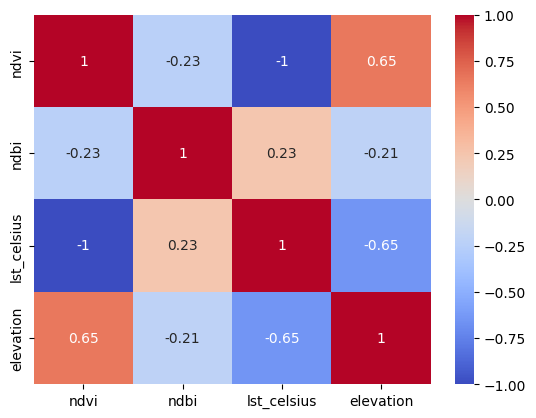

In [11]:
#Probemos a hacer un EDA rápido para ver qué tipo de datos tenemos y cómo se relacionan entre sí.
#Posibles correlaciones entre variables excluyendo coordenadas y fecha
df_bcn_corr = df_bcn.drop(['latitude', 'longitude', 'fecha'], axis=1).corr()
sns.heatmap(df_bcn_corr, annot=True, cmap='coolwarm')

Text(0.5, 1.0, 'Relación entre NDVI y NDBI')

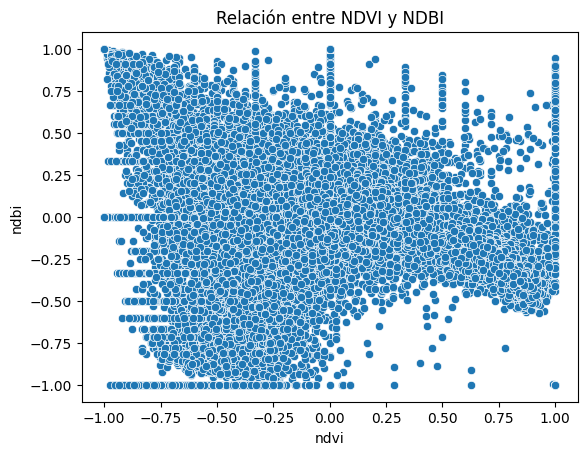

In [12]:
# Hacer un gráfico de dispersión para ver la relación entre ndvi y ndbi
sns.scatterplot(data=df_bcn, x='ndvi', y='ndbi')
plt.title('Relación entre NDVI y NDBI')

In [13]:
#standarizar ndvi y ndvi para que sean de 0 a 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_bcn[['ndvi', 'ndbi']] = scaler.fit_transform(df_bcn[['ndvi', 'ndbi']])

<Axes: xlabel='ndvi', ylabel='ndbi'>

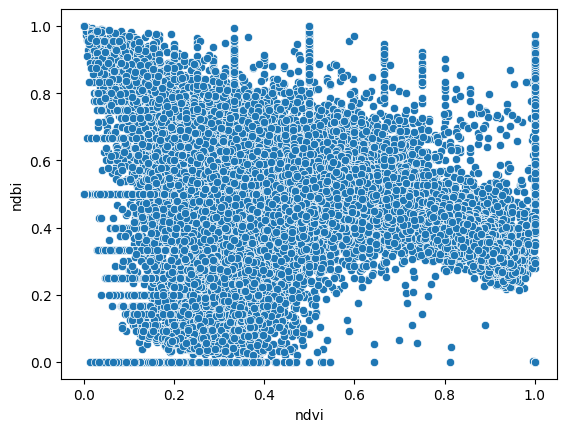

In [14]:
# graficar ndvi y ndbi después de la estandarización
sns.scatterplot(data=df_bcn, x='ndvi', y='ndbi')

In [15]:
#graficar correlación de pearson entre ndvi y ndbi
pearson_corr = df_bcn['ndvi'].corr(df_bcn['ndbi'])
print(f'Correlación de Pearson entre NDVI y NDBI: {pearson_corr}')

Correlación de Pearson entre NDVI y NDBI: -0.23438415800404405


In [16]:
#hacer modelo de regresión lineal para predecir ndbi a partir de ndvi
from sklearn.linear_model import LinearRegression
X = df_bcn[['ndvi']]
y = df_bcn['ndbi']
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


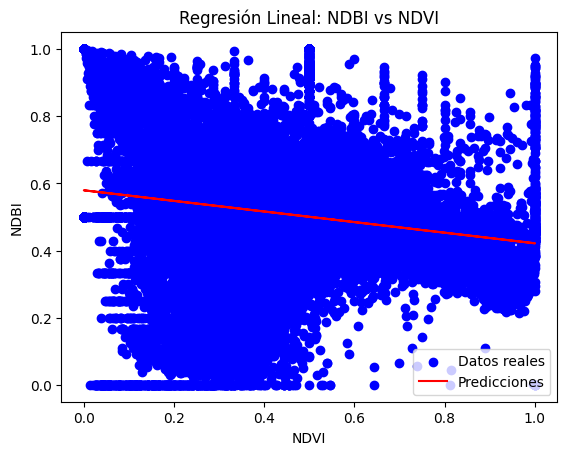

In [17]:
# hacer predicciones con el modelo
y_pred = model.predict(X)
# graficar los puntos reales y las predicciones
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X, y_pred, color='red', label='Predicciones')
plt.xlabel('NDVI')
plt.ylabel('NDBI')
plt.title('Regresión Lineal: NDBI vs NDVI')
plt.legend()
plt.show()

In [18]:
#parametros para evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 0.012325824292735762
R^2 Score: 0.05493593352326498


In [19]:
#mostrar rango de fechas de df_bcn y su distribución
print(f'Rango de fechas en df_bcn: {df_bcn["fecha"].min()} - {df_bcn["fecha"].max()}')
print(f'Distribución de fechas en df_bcn:')
df_bcn['fecha'].value_counts().sort_index()

Rango de fechas en df_bcn: 2016-07-17 - 2026-05-06
Distribución de fechas en df_bcn:


fecha
2016-07-17    500
2017-03-19    500
2017-04-03    500
2017-04-08    500
2017-05-13    500
             ... 
2026-04-16    500
2026-04-21    500
2026-04-26    500
2026-04-28    500
2026-05-06    500
Name: count, Length: 268, dtype: int64

In [20]:
df_temp.head()

,system:index,fecha,latitude,longitude,lst_day_c,lst_night_c,month,year,.geo
0,2020_01_01_0,2020-01-01,41.441185,2.128115,8.81,5.93,1,2020,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,2020_01_01_1,2020-01-01,41.441185,2.140112,9.91,6.55,1,2020,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2020_01_01_2,2020-01-01,41.441185,2.152109,11.05,6.99,1,2020,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,2020_01_01_3,2020-01-01,41.441185,2.164105,11.33,7.15,1,2020,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,2020_01_01_4,2020-01-01,41.441185,2.176102,12.21,7.19,1,2020,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [21]:
df_temp['fecha'] = pd.to_datetime(df_temp['fecha'])
df_bcn['fecha'] = pd.to_datetime(df_bcn['fecha'])

In [22]:
df_bcn = df_bcn[
    (df_bcn['fecha'] >= '2020-01-01') &
    (df_bcn['fecha'] <= '2025-12-31')
]

In [23]:
df_bcn['fecha'].nunique()

181

In [24]:
df_bcn.groupby('fecha').size().describe()

count    181.000000
mean     499.464088
std       43.723056
min      179.000000
25%      500.000000
50%      500.000000
75%      500.000000
max      803.000000
dtype: float64

PIPELINE

In [25]:
df_temp['fecha'] = pd.to_datetime(df_temp['fecha'])
df_bcn['fecha'] = pd.to_datetime(df_bcn['fecha'])

In [26]:
fechas_comunes = set(df_temp['fecha']).intersection(
    set(df_bcn['fecha'])
)

df_temp = df_temp[df_temp['fecha'].isin(fechas_comunes)]
df_bcn = df_bcn[df_bcn['fecha'].isin(fechas_comunes)]

In [27]:
gdf_temp = gpd.GeoDataFrame(
    df_temp,
    geometry=gpd.points_from_xy(
        df_temp.longitude,
        df_temp.latitude
    ),
    crs='EPSG:4326'
)

gdf_bcn = gpd.GeoDataFrame(
    df_bcn,
    geometry=gpd.points_from_xy(
        df_bcn.longitude,
        df_bcn.latitude
    ),
    crs='EPSG:4326'
)

In [28]:
gdf_temp = gdf_temp.to_crs(32631)
gdf_bcn = gdf_bcn.to_crs(32631)

In [29]:
merged_list = []

for fecha in fechas_comunes:

    temp_day = gdf_temp[gdf_temp['fecha'] == fecha]

    bcn_day = gdf_bcn[gdf_bcn['fecha'] == fecha]

    merged_day = gpd.sjoin_nearest(
        bcn_day,
        temp_day[
            [
                'lst_day_c',
                'lst_night_c',
                'geometry'
            ]
        ],
        how='left',
        distance_col='dist_m'
    )

    merged_list.append(merged_day)

dataset_final = pd.concat(
    merged_list,
    ignore_index=True
)

In [30]:
dataset_final.head()

,ndvi,ndbi,lst_celsius,elevation,longitude,latitude,fecha,geometry,index_right,lst_day_c,lst_night_c,dist_m
0,0.569319,0.534541,36.336341,187,2.153994,41.421864,2022-12-03,POINT (429304.881 4585935.047),14188,13.09,7.67,254.847100
1,0.678492,0.459089,33.716198,7,2.085892,41.334321,2022-12-03,POINT (423511.433 4576273.929),14273,17.45,8.13,259.206483
2,0.538642,0.491912,37.072586,58,2.118558,41.375535,2022-12-03,POINT (426291.341 4580821.115),14236,13.17,7.73,480.235785
3,0.894246,0.403939,28.538103,272,2.098252,41.446837,2022-12-03,POINT (424675.713 4588754.47),14166,10.33,6.33,1619.092983
4,0.046875,0.000000,48.875000,0,2.254149,41.404057,2022-12-03,POINT (437657.155 4583881.193),14194,16.21,7.43,3330.021254


In [31]:
dataset_final['dist_m'].describe()

count    12230.000000
mean      1679.086824
std       1896.503448
min          9.205649
25%        404.440213
50%        654.751781
75%       2625.359725
max       9413.432726
Name: dist_m, dtype: float64

LIMPIEZA

In [32]:
dataset_final = dataset_final.drop(
    columns=[
        'geometry',
        'index_right'
    ],
    errors='ignore'
)

In [33]:
dataset_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 12230 entries, 0 to 12229
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ndvi         12230 non-null  float64       
 1   ndbi         12230 non-null  float64       
 2   lst_celsius  12230 non-null  float64       
 3   elevation    12230 non-null  int64         
 4   longitude    12230 non-null  float64       
 5   latitude     12230 non-null  float64       
 6   fecha        12230 non-null  datetime64[us]
 7   lst_day_c    12230 non-null  float64       
 8   lst_night_c  12230 non-null  float64       
 9   dist_m       12230 non-null  float64       
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 955.6 KB


<Axes: >

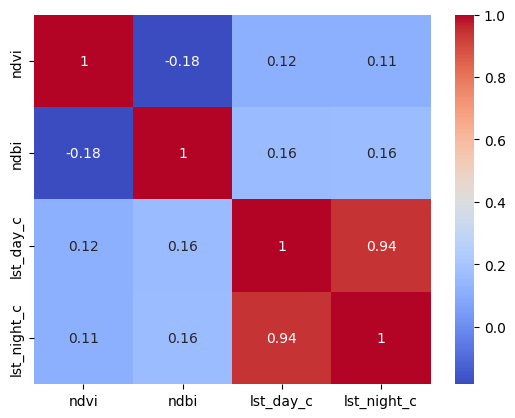

In [34]:
#MAtriz de correlación entre ndvi, ndbi, lst_day_c y lst_night_c
corr_matrix = dataset_final[
    [
        'ndvi',
        'ndbi',
        'lst_day_c',
        'lst_night_c'
    ]
].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')


In [35]:
#R2 de pearson entre ndvi y lst_day_c. y entre ndbi y lst_day_c
pearson_corr_ndvi_lst_day = dataset_final['ndvi'].corr(dataset_final['lst_day_c'])
print(f'Correlación de Pearson entre NDVI y LST Day: {pearson_corr_ndvi_lst_day}')

pearson_corr_ndbi_lst_day = dataset_final['ndbi'].corr(dataset_final['lst_day_c'])
print(f'Correlación de Pearson entre NDBI y LST Day: {pearson_corr_ndbi_lst_day}')

Correlación de Pearson entre NDVI y LST Day: 0.11534732634015482
Correlación de Pearson entre NDBI y LST Day: 0.15556245555965362


SPLIT + TRAIN

In [36]:
df_temp.groupby('fecha').size().describe()

count     24.000000
mean     106.083333
std       20.216043
min       27.000000
25%      100.500000
50%      112.500000
75%      118.000000
max      125.000000
dtype: float64

In [37]:
df_temp.groupby('fecha').size().sort_values().head(20)

fecha
2023-09-14     27
2023-05-17     86
2023-08-05     91
2024-08-04     91
2025-10-08     93
2020-08-20     93
2022-08-05    103
2020-02-02    104
2024-06-25    109
2025-01-01    110
2021-12-03    112
2023-04-07    112
2022-01-17    113
2022-12-03    113
2022-05-17    114
2021-01-17    116
2023-10-24    116
2020-07-11    118
2021-10-24    118
2025-11-09    119
dtype: int64

Filtar por imágenes con suficientes valores válidos

In [38]:
counts = df_temp.groupby('fecha').size()

fechas_validas = counts[counts >= 50].index

df_temp_filtered = df_temp[df_temp['fecha'].isin(fechas_validas)]
df_bcn_filtered = df_bcn[df_bcn['fecha'].isin(fechas_validas)]

In [39]:
print(f'Número de fechas válidas: {len(fechas_validas)}')

Número de fechas válidas: 23


GRID 1 km

In [40]:
import geopandas as gpd
import pandas as pd

gdf_bcn = gpd.GeoDataFrame(
    df_bcn,
    geometry=gpd.points_from_xy(
        df_bcn.longitude,
        df_bcn.latitude
    ),
    crs='EPSG:4326'
)

gdf_temp = gpd.GeoDataFrame(
    df_temp,
    geometry=gpd.points_from_xy(
        df_temp.longitude,
        df_temp.latitude
    ),
    crs='EPSG:4326'
)

In [41]:
gdf_bcn = gdf_bcn.to_crs(32631)
gdf_temp = gdf_temp.to_crs(32631)

In [42]:
gdf_bcn['x'] = gdf_bcn.geometry.x
gdf_bcn['y'] = gdf_bcn.geometry.y

gdf_temp['x'] = gdf_temp.geometry.x
gdf_temp['y'] = gdf_temp.geometry.y

In [43]:
GRID_SIZE = 1000

gdf_bcn['grid_x'] = (
    gdf_bcn['x'] // GRID_SIZE
).astype(int)

gdf_bcn['grid_y'] = (
    gdf_bcn['y'] // GRID_SIZE
).astype(int)

gdf_bcn['grid_id'] = (
    gdf_bcn['grid_x'].astype(str)
    + '_'
    + gdf_bcn['grid_y'].astype(str)
)

In [44]:
gdf_temp['grid_x'] = (
    gdf_temp['x'] // GRID_SIZE
).astype(int)

gdf_temp['grid_y'] = (
    gdf_temp['y'] // GRID_SIZE
).astype(int)

gdf_temp['grid_id'] = (
    gdf_temp['grid_x'].astype(str)
    + '_'
    + gdf_temp['grid_y'].astype(str)
)

In [45]:
sentinel_agg = (
    gdf_bcn
    .groupby(['fecha', 'grid_id'])
    .agg({
        'ndvi': 'mean',
        'ndbi': 'mean',
        'elevation': 'mean',
        'latitude': 'mean',
        'longitude': 'mean'
    })
    .reset_index()
)

In [46]:
modis_agg = (
    gdf_temp
    .groupby(['fecha', 'grid_id'])
    .agg({
        'lst_day_c': 'mean',
        'lst_night_c': 'mean'
    })
    .reset_index()
)

In [47]:
#MERGE
dataset_final = pd.merge(
    sentinel_agg,
    modis_agg,
    on=['fecha', 'grid_id'],
    how='inner'
)

In [48]:
dataset_final.shape

(2247, 9)

In [49]:
dataset_final.groupby('fecha').size().describe()

count     24.000000
mean      93.625000
std       18.478689
min       21.000000
25%       88.750000
50%       99.000000
75%      104.250000
max      112.000000
dtype: float64

In [50]:
dataset_final['fecha'] = pd.to_datetime(
    dataset_final['fecha']
)

dataset_final['month'] = (
    dataset_final['fecha'].dt.month
)

dataset_final['dayofyear'] = (
    dataset_final['fecha'].dt.dayofyear
)

dataset_final['year'] = (
    dataset_final['fecha'].dt.year
)

VALIDEZ

In [51]:
dataset_final.isna().mean()

fecha          0.0
grid_id        0.0
ndvi           0.0
ndbi           0.0
elevation      0.0
latitude       0.0
longitude      0.0
lst_day_c      0.0
lst_night_c    0.0
month          0.0
dayofyear      0.0
year           0.0
dtype: float64

In [52]:
dataset_final['lst_day_c'].describe()

count    2247.000000
mean       25.096044
std         9.302978
min         8.590000
25%        16.310000
50%        24.250000
75%        34.230000
max        41.330000
Name: lst_day_c, dtype: float64

In [71]:
#Crear columna de anomalia términa para lst_day_c restando la media mensual de lst_day_c a cada valor de lst_day_c
dataset_final['lst_day_c_anomaly'] = (dataset_final['lst_day_c'] - dataset_final['lst_day_c'].mean())

In [73]:
#media de temperatura 
dataset_final['lst_day_c'].mean()

np.float64(25.09604361370719)

In [74]:
#Crear columna de anomalia térmica para lst_night_c restando la media mensual de lst_night_c a cada valor de lst_night_c
dataset_final['lst_night_c_anomaly'] = (dataset_final['lst_night_c'] - dataset_final['lst_night_c'].mean())

<Axes: xlabel='lst_night_c_anomaly', ylabel='Count'>

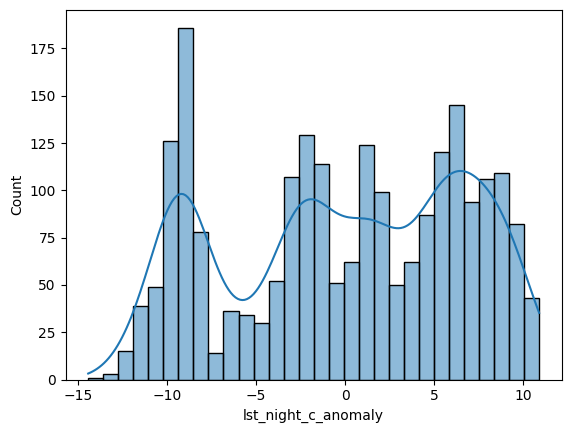

In [75]:
#histograma de lst_night_c_anomaly
sns.histplot(dataset_final['lst_night_c_anomaly'], bins=30, kde=True)

<Axes: xlabel='lst_day_c_anomaly', ylabel='Count'>

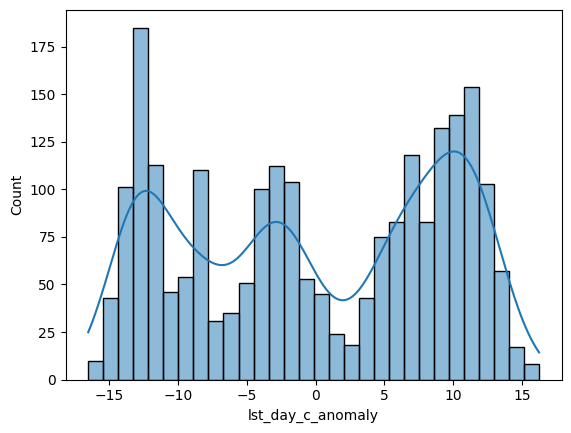

In [70]:
#histograma de lst_day_c_anomaly
sns.histplot(dataset_final['lst_day_c_anomaly'], bins=30, kde=True)

In [77]:
#Clasificar lst_day_c_anomaly en 3 categorias: baja, media y alta
dataset_final['lst_day_c_anomaly_cat'] = pd.cut(dataset_final['lst_day_c_anomaly'], bins=3, labels=['baja', 'media', 'alta'])

In [83]:
dataset_final['lst_day_c_anomaly_cat'].value_counts()

lst_day_c_anomaly_cat
alta     894
baja     728
media    625
Name: count, dtype: int64

RANDOM FOREST DE PRUEBA

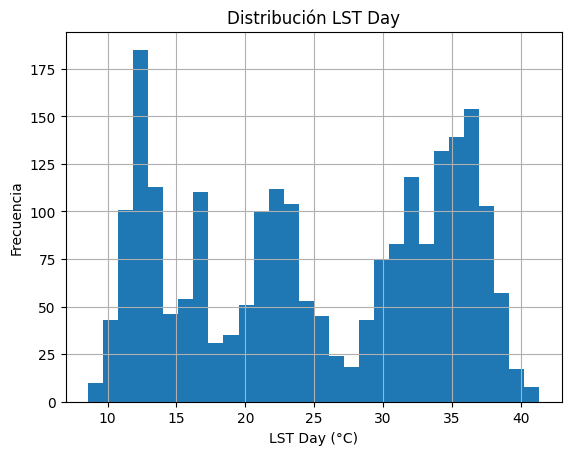

In [54]:
import matplotlib.pyplot as plt

dataset_final['lst_day_c'].hist(bins=30)

plt.xlabel('LST Day (°C)')
plt.ylabel('Frecuencia')
plt.title('Distribución LST Day')

plt.show()

Text(0.5, 0, 'Fecha')

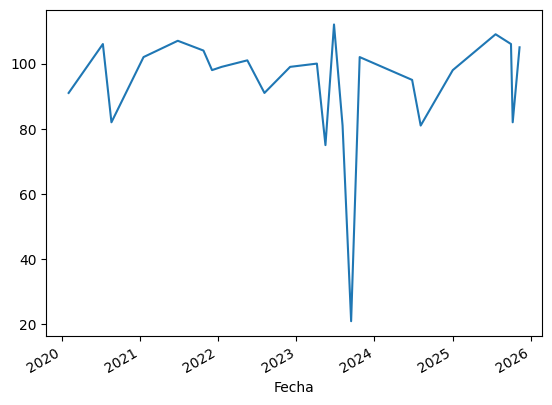

In [55]:
#Distribución visual de fechas en dataset_final
dataset_final['fecha'].value_counts().sort_index().plot(kind='line')
plt.xlabel('Fecha')


<Axes: xlabel='fecha'>

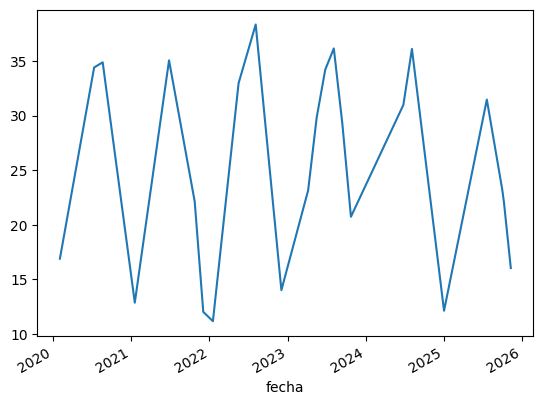

In [56]:
#Timeseries que muestre la evolución de lst_day_c a lo largo del tiempo
dataset_final.groupby('fecha')['lst_day_c'].mean().plot(kind='line')

In [57]:
train = dataset_final[
    dataset_final['year'] <= 2023
]

test = dataset_final[
    dataset_final['year'] >= 2024
]

In [58]:
features = [
    'ndvi',
    'ndbi',
    'elevation',
    'latitude',
    'longitude',
    # 'dayofyear'
]

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [60]:
rf.fit(
    train[features],
    train['lst_day_c']
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [61]:
preds = rf.predict(test[features])

In [62]:
print(test['lst_day_c'])

1571    31.01
1572    30.99
1573    31.21
1574    31.37
1575    31.91
        ...  
2242    15.99
2243    16.53
2244    14.99
2245    16.01
2246    15.97
Name: lst_day_c, Length: 676, dtype: float64


In [63]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mse = mean_squared_error(
    test['lst_day_c'],
    preds
)

rmse = np.sqrt(mse)

print('R2:', r2_score(test['lst_day_c'], preds))
print('MAE:', mean_absolute_error(test['lst_day_c'], preds))
print('RMSE:', rmse)

R2: 0.13748424396485215
MAE: 6.206037908271912
RMSE: 7.578135701177516


In [64]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

ndbi         0.351911
ndvi         0.302538
longitude    0.130167
latitude     0.113335
elevation    0.102048
dtype: float64


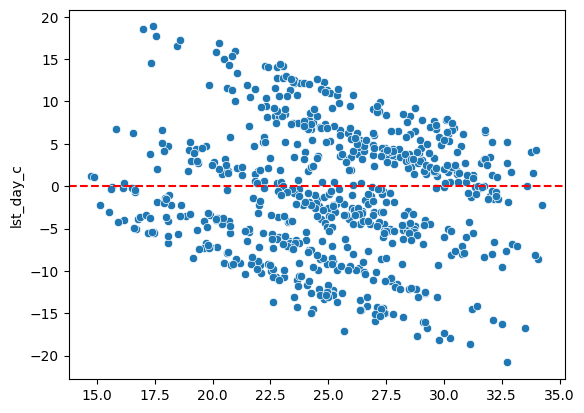

In [65]:
residuals = test['lst_day_c'] - preds
sns.scatterplot(x=preds, y=residuals)
plt.axhline(0, color='red', linestyle='--')

JOIN_GEO

In [66]:
gdf_bcn_ndvi = gpd.GeoDataFrame(
    df_bcn,
    geometry=gpd.points_from_xy(
        df_bcn.longitude,
        df_bcn.latitude
    ),
    crs="EPSG:4326"
)

gdf_bcn_ndvi = gdf_bcn_ndvi.to_crs(secciones.crs)

NameError: name 'secciones' is not defined

In [ ]:
gdf_joined = gpd.sjoin(
    gdf_bcn_ndvi,
    secciones_bcn,
    how="inner",
    predicate="within"
)

In [ ]:
sentinel_agg = (
    gdf_joined
    .groupby(['CUSEC'])
    .agg({
        'ndvi': 'mean',
        'ndbi': 'mean',
        'elevation': 'mean',
        'latitude': 'mean',
        'longitude': 'mean'
    })
    .reset_index()
)

In [ ]:
print(sentinel_agg.head())
print(sentinel_agg.shape)
sentinel_agg.info()

        CUSEC      ndvi      ndbi  elevation   latitude  longitude
0  0801501003  0.083652  0.201550       13.0  41.449233   2.248569
1  0801503001  0.059756  0.109109       10.0  41.438468   2.232810
2  0801503015  0.241142 -0.057836        6.0  41.440985   2.234319
3  0801507013  0.107843  0.156171       53.0  41.445338   2.224005
4  0801507030  0.476795 -0.050696       38.0  41.447712   2.233586
(197, 6)
<class 'pandas.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CUSEC      197 non-null    str    
 1   ndvi       197 non-null    float64
 2   ndbi       197 non-null    float64
 3   elevation  197 non-null    float64
 4   latitude   197 non-null    float64
 5   longitude  197 non-null    float64
dtypes: float64(5), str(1)
memory usage: 9.4 KB
